In [5]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("jasonrobinson1/animal-health-incident-reports")

# List all files in the dataset
files = os.listdir(path)

# Load the CSV file (adjust filename if needed)
df = pd.read_csv(os.path.join(path, files[0]))

In [6]:
# Check variables / columns
print("\n--- Shape ---")
print(df.shape)


--- Shape ---
(5579, 13)


In [7]:
print("\n--- Column Names ---")
print(df.columns.tolist())


--- Column Names ---
['report_id', 'country', 'region', 'date_reported', 'species', 'disease', 'confirmed_cases', 'deaths', 'outbreak_status', 'notes', 'source', 'latitude', 'longitude']


In [8]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
report_id           object
country             object
region             float64
date_reported       object
species             object
disease             object
confirmed_cases      int64
deaths               int64
outbreak_status     object
notes               object
source              object
latitude           float64
longitude          float64
dtype: object


In [9]:
print("\n--- First 5 Rows ---")
display(df.head())


--- First 5 Rows ---


,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,source,latitude,longitude
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,NaN,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),0,0,Resolved,First occurrence in a zone or a compartment,https://wahis.woah.org,NaN,NaN
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,NaN,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,NaN,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,NaN,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),NaN,2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),0,0,Resolved,First occurrence in the country,https://wahis.woah.org,NaN,NaN


In [10]:
print("\n--- Basic Stats ---")
display(df.describe(include='all'))


--- Basic Stats ---


,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,source,latitude,longitude
count,5579,5579,0.0,5579,5579,5579,5579.0,5579.0,5579,5579,5579,0.0,0.0
unique,5579,187,NaN,2845,7,141,NaN,NaN,1,14,1,NaN,NaN
top,5062ecd5-aa85-464c-9086-205efb4a5aac,Russia,NaN,2022-06-07,Poultry,High pathogenicity avian influenza viruses (po...,NaN,NaN,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
freq,1,340,NaN,38,2098,966,NaN,NaN,5579,3696,5579,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [11]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
report_id             0
country               0
region             5579
date_reported         0
species               0
disease               0
confirmed_cases       0
deaths                0
outbreak_status       0
notes                 0
source                0
latitude           5579
longitude          5579
dtype: int64


In [12]:
import requests
import io

# Download World Bank country classification (income group + region)
wb_url = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"
wb_response = requests.get(wb_url)
wb_raw = pd.read_excel(io.BytesIO(wb_response.content), sheet_name='List of economies', header=0)

# Keep only relevant columns and clean
wb = wb_raw[['Economy', 'Code', 'Region', 'Income group']].copy()
wb.columns = ['country_wb', 'iso_code', 'wb_region', 'income_group']
wb = wb.dropna(subset=['country_wb'])
wb = wb[wb['income_group'].notna()]  # remove aggregates (continents etc.)

print(f"World Bank data loaded: {len(wb)} countries")
print(wb['income_group'].value_counts())
print(wb['wb_region'].value_counts())

World Bank data loaded: 217 countries
income_group
High income            81
Lower middle income    54
Upper middle income    54
Low income             28
Name: count, dtype: int64
wb_region
Europe & Central Asia         58
Sub-Saharan Africa            48
Latin America & Caribbean     41
East Asia & Pacific           38
Middle East & North Africa    21
South Asia                     8
North America                  3
Name: count, dtype: int64


In [13]:
name_map = {
    # Original mappings
    "China (People's Rep. of)": "China",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Korea (Rep. of)": "Korea, Rep.",
    "Iran (Islamic Rep. of)": "Iran, Islamic Rep.",
    "Taiwan": "Taiwan, China",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Rep. of)": "Venezuela, RB",
    "Tanzania (United Rep. of)": "Tanzania",
    "Congo (Dem. Rep. of the)": "Congo, Dem. Rep.",
    "Congo": "Congo, Rep.",
    "Lao (People's Dem. Rep.)": "Lao PDR",
    "Viet Nam": "Vietnam",
    "Czechia": "Czech Republic",
    "North Macedonia": "North Macedonia",
    "Eswatini": "Eswatini",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Syrian Arab Republic": "Syrian Arab Republic",
    "Libya": "Libya",
    "Kosovo": "Kosovo",

    # Extended mappings
    'Russia': 'Russian Federation',
    'Egypt': 'Egypt, Arab Rep.',
    'Iran': 'Iran, Islamic Rep.',
    'Syria': 'Syrian Arab Republic',
    'Türkiye (Rep. of)': 'Turkiye',
    'Venezuela': 'Venezuela, RB',
    'Slovakia': 'Slovak Republic',
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Laos': 'Lao PDR',
    'Brunei': 'Brunei Darussalam',
    'Gambia': 'Gambia, The',
    "Cote D'Ivoire": "Cote d'Ivoire",
    'Congo (Rep. of the)': 'Congo, Rep.',
    'Central African (Rep.)': 'Central African Republic',
    'Dominican (Rep.)': 'Dominican Republic',
    "Korea (Dem People's Rep. of)": "Korea, Dem. People's Rep.",
    'South Sudan (Rep. of)': 'South Sudan',
    'Cabo verde': 'Cabo Verde',
    'Chinese Taipei': 'Taiwan, China',
    'Hong Kong': 'Hong Kong SAR, China',
    'Venezuela' : 'Venezuela, RB',

    # Territories
    'French Guiana': 'France',
    'Guadeloupe': 'France',
    'Martinique': 'France',
    'Reunion': 'France',
    'Mayotte': 'France',
    'Faeroe Islands': 'Denmark',
    'Falkland Islands (Malvinas)': 'United Kingdom',
    'St. Helena': 'United Kingdom',
    'Ceuta': 'Spain',
    'Melilla': 'Spain',
}

df['country_mapped'] = df['country'].replace(name_map)


In [14]:

df_enriched = df.merge(
    wb[['country_wb', 'iso_code', 'wb_region', 'income_group']],
    left_on='country_mapped',
    right_on='country_wb',
    how='left'
)

# Check merge success rate
total = len(df_enriched)
matched = df_enriched['income_group'].notna().sum()
unmatched = df_enriched[df_enriched['income_group'].isna()]['country'].unique()

print(f"\n✅ Matched: {matched}/{total} ({matched/total*100:.1f}%)")
print(f"\n❌ Unmatched countries ({len(unmatched)}):")
print(sorted(unmatched))


✅ Matched: 5486/5579 (98.3%)

❌ Unmatched countries (7):
['Antarctica', "Cote D'Ivoire", 'Palestine', 'Serbia and Montenegro', 'South Georgia and the South Sandwich Islands', 'Türkiye (Rep. of)', 'Venezuela']


In [15]:
df_enriched['date_reported'] = pd.to_datetime(df_enriched['date_reported'], errors='coerce')

df_enriched['year'] = df_enriched['date_reported'].dt.year
df_enriched['month'] = df_enriched['date_reported'].dt.month
df_enriched['season'] = df_enriched['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# ============================================================
# STEP 7: Final check
# ============================================================

print("\n--- Enriched Dataset Info ---")
print(df_enriched[['country', 'wb_region', 'income_group', 'year', 'season']].head(10))
print(f"\nShape: {df_enriched.shape}")
print(f"\nNew columns added: wb_region, income_group, iso_code, year, month, season")


--- Enriched Dataset Info ---
                    country                   wb_region         income_group  \
0                  Mongolia         East Asia & Pacific  Lower middle income   
1                     Niger          Sub-Saharan Africa           Low income   
2                    Israel  Middle East & North Africa          High income   
3                Kazakhstan       Europe & Central Asia  Upper middle income   
4  China (People's Rep. of)         East Asia & Pacific  Upper middle income   
5                    Russia       Europe & Central Asia  Upper middle income   
6                    Russia       Europe & Central Asia  Upper middle income   
7                   Finland       Europe & Central Asia          High income   
8                    Zambia          Sub-Saharan Africa           Low income   
9                   Vietnam         East Asia & Pacific  Lower middle income   

   year  season  
0  2022  Spring  
1  2022  Spring  
2  2022  Spring  
3  2022  Spring 

In [16]:
df_enriched.head()

,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,...,latitude,longitude,country_mapped,country_wb,iso_code,wb_region,income_group,year,month,season
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,NaN,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),0,0,Resolved,First occurrence in a zone or a compartment,...,NaN,NaN,Mongolia,Mongolia,MNG,East Asia & Pacific,Lower middle income,2022,3,Spring
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,NaN,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,...,NaN,NaN,Niger,Niger,NER,Sub-Saharan Africa,Low income,2022,3,Spring
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,NaN,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,0,0,Resolved,Recurrence of an eradicated disease,...,NaN,NaN,Israel,Israel,ISR,Middle East & North Africa,High income,2022,3,Spring
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,NaN,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,...,NaN,NaN,Kazakhstan,Kazakhstan,KAZ,Europe & Central Asia,Upper middle income,2022,3,Spring
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),NaN,2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),0,0,Resolved,First occurrence in the country,...,NaN,NaN,China,China,CHN,East Asia & Pacific,Upper middle income,2022,3,Spring


In [17]:
df_enriched = df_enriched.drop(columns=['region', 'confirmed_cases', 'deaths', 'longitude', 'latitude', 'country_mapped', 'country_wb'])

print(df_enriched.shape)
df_enriched.head()

(5579, 14)


,report_id,country,date_reported,species,disease,outbreak_status,notes,source,iso_code,wb_region,income_group,year,month,season
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),Resolved,First occurrence in a zone or a compartment,https://wahis.woah.org,MNG,East Asia & Pacific,Lower middle income,2022,3,Spring
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NER,Sub-Saharan Africa,Low income,2022,3,Spring
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,ISR,Middle East & North Africa,High income,2022,3,Spring
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,KAZ,Europe & Central Asia,Upper middle income,2022,3,Spring
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),Resolved,First occurrence in the country,https://wahis.woah.org,CHN,East Asia & Pacific,Upper middle income,2022,3,Spring


Numerical columns: ['year', 'month']

--- Summary Statistics ---


,year,month
count,5579.000000,5579.000000
mean,2017.805521,6.366912
std,5.665689,3.548666
min,2005.000000,1.000000
25%,2014.000000,3.000000
50%,2019.000000,6.000000
75%,2022.000000,10.000000
max,2025.000000,12.000000


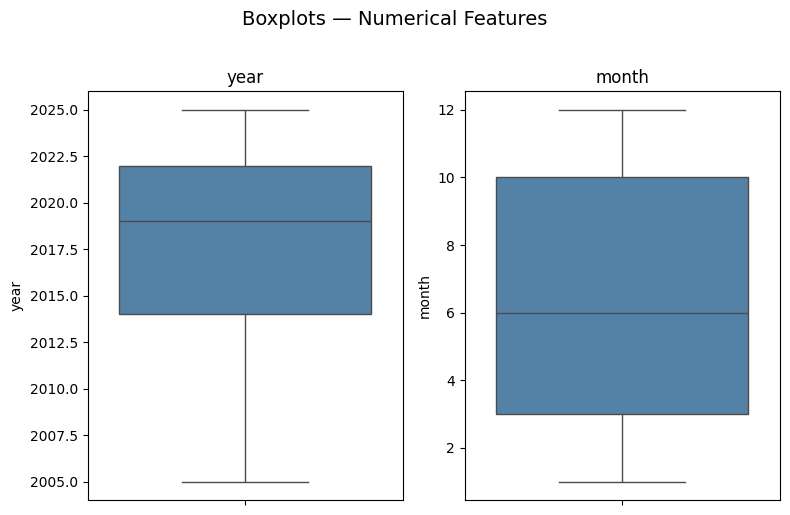


--- IQR Outlier Counts ---
year: 0 outliers (0.0%)
month: 0 outliers (0.0%)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Outlier Check — Numerical Columns
# ============================================================

numerical_cols = df_enriched.select_dtypes(include='number').columns.tolist()
print("Numerical columns:", numerical_cols)

# Summary stats
print("\n--- Summary Statistics ---")
display(df_enriched[numerical_cols].describe())

# Boxplots for each numerical column
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4 * len(numerical_cols), 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_enriched[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Boxplots — Numerical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# IQR-based Outlier Count per Column
# ============================================================

print("\n--- IQR Outlier Counts ---")
for col in numerical_cols:
    Q1 = df_enriched[col].quantile(0.25)
    Q3 = df_enriched[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_enriched[(df_enriched[col] < Q1 - 1.5 * IQR) | (df_enriched[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_enriched)*100:.1f}%)")

In [19]:
print(df_enriched['notes'].unique())

['First occurrence in a zone or a compartment'
 'Recurrence of an eradicated disease' 'First occurrence in the country'
 'New strain in the country' 'Emerging disease' 'Unusual host species'
 'Recurrence' 'Recurrence of an eradicated strain'
 'New strain in a zone or a compartment'
 'Listed disease occurring in a new host species'
 'Unexpected change or increase'
 'New pathogen strain or disease manifestation' 'Change in epidemiology'
 'New host']


In [20]:
print(df_enriched.isnull().sum())
print()
print(f"Total missing: {df_enriched.isnull().sum().sum()}")

report_id           0
country             0
date_reported       0
species             0
disease             0
outbreak_status     0
notes               0
source              0
iso_code           93
wb_region          93
income_group       93
year                0
month               0
season              0
dtype: int64

Total missing: 279


In [21]:
print(df_enriched.select_dtypes(include='number').columns.tolist())

['year', 'month']


In [22]:
dist = df_enriched['notes'].value_counts()
pct = df_enriched['notes'].value_counts(normalize=True) * 100

for label in dist.index:
    print(f"{label}: {dist[label]} ({pct[label]:.1f}%)")

Recurrence of an eradicated disease: 3696 (66.2%)
First occurrence in a zone or a compartment: 779 (14.0%)
First occurrence in the country: 266 (4.8%)
Emerging disease: 197 (3.5%)
New strain in the country: 166 (3.0%)
Recurrence: 143 (2.6%)
New strain in a zone or a compartment: 136 (2.4%)
Recurrence of an eradicated strain: 95 (1.7%)
Unusual host species: 42 (0.8%)
Unexpected change or increase: 37 (0.7%)
Change in epidemiology: 7 (0.1%)
Listed disease occurring in a new host species: 6 (0.1%)
New pathogen strain or disease manifestation: 5 (0.1%)
New host: 4 (0.1%)


## Missing Value Handling

Fill unmatched `wb_region` and `income_group` with `'Unknown'`. These 93 rows represent territories/disputed regions — dropping them would silently remove real outbreak records.

In [23]:
# Fill missing wb_region and income_group with 'Unknown'
# (93 rows where country couldn't be matched to World Bank data)
df_enriched['wb_region'] = df_enriched['wb_region'].fillna('Unknown')
df_enriched['income_group'] = df_enriched['income_group'].fillna('Unknown')

# Drop iso_code — not used as a model feature
if 'iso_code' in df_enriched.columns:
    df_enriched = df_enriched.drop(columns=['iso_code'])

# Drop source, report_id, outbreak_status — constant or identifier columns
drop_cols = [c for c in ['source', 'report_id', 'outbreak_status'] if c in df_enriched.columns]
df_enriched = df_enriched.drop(columns=drop_cols)

print('Missing values after filling:')
print(df_enriched.isnull().sum())
print(f'\nShape: {df_enriched.shape}')
print(f'\nColumns remaining: {df_enriched.columns.tolist()}')

Missing values after filling:
country          0
date_reported    0
species          0
disease          0
notes            0
wb_region        0
income_group     0
year             0
month            0
season           0
dtype: int64

Shape: (5579, 10)

Columns remaining: ['country', 'date_reported', 'species', 'disease', 'notes', 'wb_region', 'income_group', 'year', 'month', 'season']


## Temporal Train/Test Split

In [24]:
# Temporal train/test split — must happen BEFORE any feature fitting
train_df = df_enriched[df_enriched['year'] <= 2019].copy()
val_df   = df_enriched[(df_enriched['year'] >= 2020) & (df_enriched['year'] <= 2022)].copy()
test_df  = df_enriched[df_enriched['year'] >= 2023].copy()


print(f'Train set: {len(train_df)} rows  ({train_df["year"].min()}–{train_df["year"].max()})')
print(f'Val set:  {len(val_df)} rows  ({val_df["year"].min()}–{val_df["year"].max()})')
print(f'Test set:  {len(test_df)} rows  ({test_df["year"].min()}–{test_df["year"].max()})')


print(f'\nTrain class distribution:')
print(train_df['notes'].value_counts())
print(f'\nVal class distribution:')
print(val_df['notes'].value_counts())
print(f'\nTest class distribution:')
print(test_df['notes'].value_counts())

Train set: 2878 rows  (2005–2019)
Val set:  1325 rows  (2020–2022)
Test set:  1376 rows  (2023–2025)

Train class distribution:
notes
Recurrence of an eradicated disease               1913
First occurrence in a zone or a compartment        475
Emerging disease                                    97
New strain in a zone or a compartment               95
Recurrence                                          83
First occurrence in the country                     83
New strain in the country                           76
Unexpected change or increase                       30
Change in epidemiology                               7
Listed disease occurring in a new host species       6
New pathogen strain or disease manifestation         5
Unusual host species                                 5
New host                                             3
Name: count, dtype: int64

Val class distribution:
notes
Recurrence of an eradicated disease            887
First occurrence in a zone or a compartment

## Feature Engineering

All aggregations are computed **on train only**, then joined to test. This prevents leakage: test rows cannot see their own future counts.

**Features engineered:**
1. `outbreaks_per_country_year` — how active is this country in a given year
2. `outbreaks_per_disease_year` — how widespread is this disease globally in a given year
3. `outbreaks_per_species_year` — how frequently is this species affected in a given year
4. `disease_income` — interaction feature combining disease and income group

In [25]:
# ---------------------------
# 1️⃣ Outbreak frequency aggregations (fit on TRAIN only)
# ---------------------------

# Compute counts per group from training set only
country_year_counts = (
    train_df.groupby(['country', 'year'])
            .size()
            .reset_index(name='outbreaks_per_country_year')
)

disease_year_counts = (
    train_df.groupby(['disease', 'year'])
            .size()
            .reset_index(name='outbreaks_per_disease_year')
)

species_year_counts = (
    train_df.groupby(['species', 'year'])
            .size()
            .reset_index(name='outbreaks_per_species_year')
)

# Function to add frequency features to any dataframe
def add_freq_features(df, country_year_counts, disease_year_counts, species_year_counts):
    df = df.merge(country_year_counts, on=['country', 'year'], how='left')
    df = df.merge(disease_year_counts,  on=['disease', 'year'],  how='left')
    df = df.merge(species_year_counts,  on=['species', 'year'],  how='left')
    # Fill NaN (unseen combinations in val/test) with 0
    df['outbreaks_per_country_year'] = df['outbreaks_per_country_year'].fillna(0)
    df['outbreaks_per_disease_year']  = df['outbreaks_per_disease_year'].fillna(0)
    df['outbreaks_per_species_year']  = df['outbreaks_per_species_year'].fillna(0)
    return df

# Apply to train, validation, and test sets
train_df = add_freq_features(train_df, country_year_counts, disease_year_counts, species_year_counts)
val_df   = add_freq_features(val_df,   country_year_counts, disease_year_counts, species_year_counts)
test_df  = add_freq_features(test_df,  country_year_counts, disease_year_counts, species_year_counts)

print('Frequency features added. Sample from training set:')
print(train_df[['country','disease','species','year',
                 'outbreaks_per_country_year','outbreaks_per_disease_year',
                 'outbreaks_per_species_year']].head(10))

Frequency features added. Sample from training set:
          country                                            disease  species  \
0          Israel                       Bluetongue virus (Inf. with)  Unknown   
1          Latvia                Newcastle disease virus (Inf. with)  Poultry   
2  United Kingdom                Newcastle disease virus (Inf. with)  Poultry   
3         Germany            Classical swine fever virus (Inf. with)    Swine   
4        Botswana           Foot and mouth disease virus (Inf. with)   Cattle   
5        Thailand  High pathogenicity avian influenza viruses (po...  Poultry   
6         Morocco    Epizootic hemorrhagic disease virus (Inf. with)  Unknown   
7         Croatia  High pathogenicity avian influenza viruses (po...  Poultry   
8    South Africa  High pathogenicity avian influenza viruses (po...  Poultry   
9         Albania  High pathogenicity avian influenza viruses (po...  Poultry   

   year  outbreaks_per_country_year  outbreaks_per_disea

In [26]:

# Function to create short disease label
def create_disease_short(df):
    return df['disease'].str.split('(').str[0].str.strip()

# Apply to train, val, and test sets
train_df['disease_short'] = create_disease_short(train_df)
val_df['disease_short']   = create_disease_short(val_df)
test_df['disease_short']  = create_disease_short(test_df)

## Target Encoding 


In [27]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define target and features to encode
TARGET = 'notes'


# Encode target on training data
le = LabelEncoder()
y_train = le.fit_transform(train_df[TARGET])

# ---------------------------
# Validation set
# ---------------------------
# Keep only labels seen in training
val_mask = val_df[TARGET].isin(le.classes_)
val_df_filtered = val_df[val_mask].copy()
y_val = le.transform(val_df_filtered[TARGET])

# ---------------------------
# Test set
# ---------------------------
# Keep only labels seen in training
test_mask = test_df[TARGET].isin(le.classes_)
test_df_filtered = test_df[test_mask].copy()
y_test = le.transform(test_df_filtered[TARGET])

# Check
print(f"Number of training classes: {len(le.classes_)}")
print(f"Validation set size after filtering: {len(val_df_filtered)}")
print(f"Test set size after filtering: {len(test_df_filtered)}")





Number of training classes: 13
Validation set size after filtering: 1309
Test set size after filtering: 1297


## Feature Encoding 

In [28]:
CATEGORICAL_FEATURES = [
  'country',
  'species',
  'wb_region',
  'income_group',
  'season',
  'disease_short'
]

NUMERIC_FEATURES = [
    'year',
    'month',
    'outbreaks_per_country_year',
    'outbreaks_per_disease_year',
    'outbreaks_per_species_year',
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train = train_df[FEATURE_COLUMNS]
X_val   = val_df_filtered[FEATURE_COLUMNS]
X_test  = test_df_filtered[FEATURE_COLUMNS]

## Preprocessing Pipeline

In [29]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
        ('num', 'passthrough', NUMERIC_FEATURES)
    ]
)

## DummyClassifier Baseline

Always predicts the majority class. This sets the minimum bar every model must beat.

In [30]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

## Decision Tree

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

## Fit and Evaluate Models (No Tuning)

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

# Train + evaluate
evaluate_model(
    "Dummy Classifier",
    dummy_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Decision Tree",
    dt_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)


=== Dummy Classifier ===
Accuracy : 0.6776
Precision: 0.4592
Recall   : 0.6776
F1-score : 0.5474

=== Decision Tree ===
Accuracy : 0.6165
Precision: 0.5846
Recall   : 0.6165
F1-score : 0.5756


## Decision Tree Pipeline (Hyperparameter Tuning)

In [33]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate


k_fold = KFold(n_splits=5, shuffle=True, random_state=1234)
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

dt_perf = cross_validate(dt_pipeline, X_train, y_train, cv=k_fold, scoring=scoring_metrics)

pd.DataFrame(dt_perf).mean()

C:\Users\Keeto\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Keeto\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Keeto\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

fit_time                   0.028630
score_time                 0.007330
test_accuracy              0.667475
test_precision_weighted    0.669409
test_recall_weighted       0.667475
test_f1_weighted           0.666789
test_f1_macro              0.330310
dtype: float64

In [34]:
dt_step_name = dt_pipeline.steps[1][0]
step_prefix = '__'
dt_step_prefix = f"{dt_step_name}{step_prefix}"
dt_step_prefix

'classifier__'

In [35]:
dt_max_depth_key = dt_step_prefix + 'max_depth'
alpha_key = dt_step_prefix + 'ccp_alpha'
criterion_key = dt_step_prefix + 'criterion'

In [36]:
from sklearn.model_selection import GridSearchCV

def explore_single_hp_values(pipeline, param_name, param_values, X_train, y_train, k_fold, scoring):
    param_grid = {param_name: param_values}
    grid_search = GridSearchCV(pipeline, param_grid, cv=k_fold, scoring=scoring)
    grid_search.fit(X_train, y_train)
    result_columns = [f"param_{param_name}", "mean_test_score", "std_test_score", "rank_test_score"]
    return pd.DataFrame(grid_search.cv_results_)[result_columns]



In [37]:
explore_single_hp_values(dt_pipeline, dt_max_depth_key, [20, 25, 30, 35], X_train, y_train, k_fold, 'f1_weighted')

,param_classifier__max_depth,mean_test_score,std_test_score,rank_test_score
0,20,0.673774,0.015689,2
1,25,0.675816,0.012696,1
2,30,0.672279,0.007971,3
3,35,0.668327,0.011157,4


In [38]:
explore_single_hp_values(dt_pipeline, alpha_key, [0.0, 0.001, 0.002, 0.003], X_train, y_train, k_fold, 'f1_weighted')

,param_classifier__ccp_alpha,mean_test_score,std_test_score,rank_test_score
0,0.000,0.666789,0.005845,2
1,0.001,0.678339,0.020588,1
2,0.002,0.656866,0.017912,3
3,0.003,0.634533,0.013218,4


In [39]:
dt_param_grid = {dt_max_depth_key : [20, 25, 30, 35],
                 alpha_key : [0.0, 0.001, 0.002, 0.003],
                 criterion_key : ['gini', 'entropy', 'log_loss']}
grid_search_dt = GridSearchCV(dt_pipeline, dt_param_grid, cv=k_fold, scoring='f1_weighted')
grid_search_dt.fit(X_train, y_train)

grid_search_dt.best_params_

{'classifier__ccp_alpha': 0.001,
 'classifier__criterion': 'gini',
 'classifier__max_depth': 35}

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_gridsearch_heatmap(results_df, x_param, y_param, score='mean_test_score'):    
    # Pivot the table to format it for a heatmap
    heatmap_data = results_df.pivot(index=f'param_{y_param}', columns=f'param_{x_param}', values=score)
    
    # Plot heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f', linewidths=0.5)
    plt.title(f'Grid Search Results: {score}')
    plt.xlabel(x_param)
    plt.ylabel(y_param)
    plt.show()

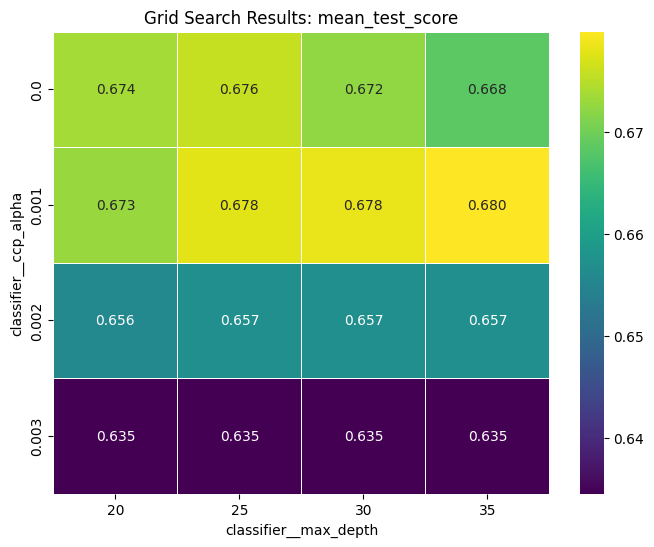

In [41]:
results = pd.DataFrame(grid_search_dt.cv_results_)
results = results[results['param_' + criterion_key] == 'gini']
plot_gridsearch_heatmap(results, dt_max_depth_key, alpha_key)

## Re-Evaluate DT vs DT Tuned vs Baseline

In [42]:
evaluate_model(
    "Dummy Classifier",
    dummy_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Decision Tree",
    dt_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Decision Tree (Tuned)",
    grid_search_dt,
    X_train,
    y_train,
    X_val,
    y_val
)


=== Dummy Classifier ===
Accuracy : 0.6776
Precision: 0.4592
Recall   : 0.6776
F1-score : 0.5474

=== Decision Tree ===
Accuracy : 0.6165
Precision: 0.5846
Recall   : 0.6165
F1-score : 0.5756

=== Decision Tree (Tuned) ===
Accuracy : 0.6516
Precision: 0.6158
Recall   : 0.6516
F1-score : 0.5910


## Random Forest

In [43]:
# imports
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [44]:
# Experiment 1: SMOTE vs No SMOTE
rf_no_smote_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [45]:
# K-fold cross validation
k_fold = KFold(n_splits=5, shuffle=True, random_state=1234)
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

rf_no_smote_perf = cross_validate(
    rf_no_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics
)

pd.DataFrame(rf_no_smote_perf).mean()

rf_smote_perf = cross_validate(
    rf_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics
)

pd.DataFrame(rf_smote_perf).mean()

C:\Users\Keeto\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Keeto\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Keeto\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

fit_time                   0.457582
score_time                 0.030066
test_accuracy              0.718206
test_precision_weighted    0.678984
test_recall_weighted       0.718206
test_f1_weighted           0.682600
test_f1_macro              0.321729
dtype: float64

In [46]:
# Evaluate experiment results
rf_experiment_1_results = pd.DataFrame([
    {
        'pipeline': 'Random Forest - No SMOTE',
        'mean_accuracy': pd.DataFrame(rf_no_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(rf_no_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(rf_no_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(rf_no_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(rf_no_smote_perf)['test_f1_macro'].mean()
    },
    {
        'pipeline': 'Random Forest - SMOTE',
        'mean_accuracy': pd.DataFrame(rf_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(rf_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(rf_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(rf_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(rf_smote_perf)['test_f1_macro'].mean()
    }
])

rf_experiment_1_results.sort_values('mean_f1_macro', ascending=False)

use_smote_for_rf = (
    pd.DataFrame(rf_smote_perf)['test_f1_macro'].mean() >
    pd.DataFrame(rf_no_smote_perf)['test_f1_macro'].mean()
)

print('Use SMOTE for Random Forest?', use_smote_for_rf)

Use SMOTE for Random Forest? False


In [47]:
rf_pipeline = rf_no_smote_pipeline

In [48]:
# Random Forest Hyperparameter Tuning
rf_n_estimators_key = 'classifier__n_estimators'
rf_max_depth_key = 'classifier__max_depth'
rf_max_features_key = 'classifier__max_features'
rf_class_weight_key = 'classifier__class_weight'

In [49]:
# Initial grid values from design document for n-estimators
explore_single_hp_values(rf_pipeline, rf_n_estimators_key, [50, 100, 200], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__n_estimators,mean_test_score,std_test_score,rank_test_score
0,50,0.335316,0.046891,1
1,100,0.328553,0.029530,3
2,200,0.333895,0.050284,2


In [50]:
# Improved n-estimator values
explore_single_hp_values(rf_pipeline, rf_n_estimators_key, [55, 60, 65], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__n_estimators,mean_test_score,std_test_score,rank_test_score
0,55,0.332021,0.040088,3
1,60,0.349558,0.043234,1
2,65,0.335375,0.042291,2


In [51]:
# Initial grid values from design document for max depth
explore_single_hp_values(rf_pipeline, rf_max_depth_key, [3, 5, 10], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__max_depth,mean_test_score,std_test_score,rank_test_score
0,3,0.070856,0.007785,3
1,5,0.074638,0.010348,2
2,10,0.112778,0.021992,1


In [52]:
# Improved max depth values
explore_single_hp_values(rf_pipeline, rf_max_depth_key, [80, 100, 120], X_train, y_train, k_fold, 'f1_macro')

,param_classifier__max_depth,mean_test_score,std_test_score,rank_test_score
0,80,0.328080,0.029567,3
1,100,0.328553,0.029530,1
2,120,0.328553,0.029530,1


In [53]:
rf_param_grid = {
    rf_n_estimators_key: [50, 60, 70],
    rf_max_depth_key: [80, 100, 120],
    rf_max_features_key: ['sqrt', 'log2'],
    rf_class_weight_key: [None, 'balanced']
}

grid_search_rf = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=k_fold,
    scoring='f1_macro'
)

grid_search_rf.fit(X_train, y_train)

grid_search_rf.best_params_

{'classifier__class_weight': None,
 'classifier__max_depth': 100,
 'classifier__max_features': 'sqrt',
 'classifier__n_estimators': 60}

In [54]:
grid_search_rf.best_score_

rf_results = pd.DataFrame(grid_search_rf.cv_results_)
rf_results.sort_values('mean_test_score', ascending=False).head(10)

evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_train,
    y_train,
    X_val,
    y_val
)

evaluate_model(
    "Random Forest (Tuned)",
    grid_search_rf,
    X_train,
    y_train,
    X_val,
    y_val
)


=== Random Forest ===
Accuracy : 0.6684
Precision: 0.5660
Recall   : 0.6684
F1-score : 0.5675

=== Random Forest (Tuned) ===
Accuracy : 0.6707
Precision: 0.5773
Recall   : 0.6707
F1-score : 0.5747


## AdaBoost

In [118]:
#Imports
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, KFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [119]:
k_fold = KFold(n_splits=5, shuffle=True, random_state=1234)
scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']

In [120]:
#SMOTE vs. no SMOTE 
# AdaBoost - No SMOTE
ada_no_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

ada_smote_pipeline = ImbPipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=1)),
    ('classifier', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

In [121]:
# 5-fold CV for SMOTE vs. no SMOTE 
ada_no_smote_perf = cross_validate(
    ada_no_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics,
    n_jobs=-1
)

ada_smote_perf = cross_validate(
    ada_smote_pipeline,
    X_train,
    y_train,
    cv=k_fold,
    scoring=scoring_metrics,
    n_jobs=-1
)

In [122]:
# Create Table 
ada_experiment_1_results = pd.DataFrame([
    {
        'pipeline': 'AdaBoost - No SMOTE',
        'mean_accuracy': pd.DataFrame(ada_no_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(ada_no_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(ada_no_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(ada_no_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(ada_no_smote_perf)['test_f1_macro'].mean()
    },
    {
        'pipeline': 'AdaBoost - SMOTE',
        'mean_accuracy': pd.DataFrame(ada_smote_perf)['test_accuracy'].mean(),
        'mean_precision_weighted': pd.DataFrame(ada_smote_perf)['test_precision_weighted'].mean(),
        'mean_recall_weighted': pd.DataFrame(ada_smote_perf)['test_recall_weighted'].mean(),
        'mean_f1_weighted': pd.DataFrame(ada_smote_perf)['test_f1_weighted'].mean(),
        'mean_f1_macro': pd.DataFrame(ada_smote_perf)['test_f1_macro'].mean()
    }
])

display(ada_experiment_1_results.sort_values('mean_f1_macro', ascending=False))

use_smote_for_ada = (
    pd.DataFrame(ada_smote_perf)['test_f1_macro'].mean() >
    pd.DataFrame(ada_no_smote_perf)['test_f1_macro'].mean()
)

print("Use SMOTE for AdaBoost:", use_smote_for_ada)

,pipeline,mean_accuracy,mean_precision_weighted,mean_recall_weighted,mean_f1_weighted,mean_f1_macro
1,AdaBoost - SMOTE,0.711606,0.681576,0.711606,0.690395,0.325923
0,AdaBoost - No SMOTE,0.700841,0.665288,0.700841,0.673773,0.314763


Use SMOTE for AdaBoost: True


In [123]:
# Moves best performer on 
if use_smote_for_ada:
    ada_pipeline = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=1)),
        ('classifier', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ))
    ])
else:
    ada_pipeline = ImbPipeline(steps=[
        ('preprocessing', preprocessor),
        ('classifier', AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            random_state=42
        ))
    ])

In [124]:
#Grid Paratmeter Names

ada_param_grid = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__estimator__max_depth': [1, 2]
}


In [125]:
grid_search_ada = GridSearchCV(
    ada_pipeline,
    ada_param_grid,
    cv=k_fold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_ada.fit(X_train, y_train)

print("Best Params:", grid_search_ada.best_params_)
print("Best CV F1-macro:", grid_search_ada.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Params: {'classifier__estimator__max_depth': 2, 'classifier__learning_rate': 0.2, 'classifier__n_estimators': 300}
Best CV F1-macro: 0.16393030345673495


In [126]:
ada_results = pd.DataFrame(grid_search_ada.cv_results_)
display(
    ada_results.sort_values('mean_test_score', ascending=False)[[
        'param_classifier__n_estimators',
        'param_classifier__learning_rate',
        'param_classifier__estimator__max_depth',
        'mean_test_score',
        'std_test_score',
        'rank_test_score'
    ]].head(10)
)

,param_classifier__n_estimators,param_classifier__learning_rate,param_classifier__estimator__max_depth,mean_test_score,std_test_score,rank_test_score
31,300,0.20,2,0.163930,0.033841,1
30,200,0.20,2,0.152367,0.038303,2
26,200,0.10,2,0.144936,0.060801,3
27,300,0.10,2,0.143976,0.045159,4
25,100,0.10,2,0.132703,0.054380,5
24,50,0.10,2,0.131194,0.053115,6
28,50,0.20,2,0.128829,0.046382,7
29,100,0.20,2,0.126102,0.035288,8
22,200,0.05,2,0.124310,0.049200,9
23,300,0.05,2,0.121894,0.052588,10


In [127]:
#AdaBoost Selection
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_adaboost_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"F1-weighted : {f1_weighted:.4f}")
    print(f"F1-macro    : {f1_macro:.4f}")

In [128]:
#Evaluation

ada_pipeline.fit(X_train, y_train)

evaluate_adaboost_model(
    "AdaBoost",
    ada_pipeline,
    X_val,
    y_val
)

evaluate_adaboost_model(
    "AdaBoost (Tuned)",
    grid_search_ada,
    X_val,
    y_val
)


=== AdaBoost ===
Accuracy    : 0.6333
Precision   : 0.5502
Recall      : 0.6333
F1-weighted : 0.5688
F1-macro    : 0.1785

=== AdaBoost (Tuned) ===
Accuracy    : 0.0611
Precision   : 0.0677
Recall      : 0.0611
F1-weighted : 0.0111
F1-macro    : 0.0201
